In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import os
import seaborn as sns
import statistics as st

In [4]:
# Load the data
data_path = 'water_consumption.csv'
water_data = pd.read_csv(data_path)

# Show the first few rows of the dataframe and data types to understand its structure
water_data.head() 

,Park;Year;Month;Day;Consumption
Oriental;2023;1;1;20,8.0
ArcaAgua;2023;1;1;5,2.0
Covelo;2023;1;1;9,27.0
Cidade;2023;1;1;68,25.0
Oriental;2023;1;2;19,NaN


In [5]:
# Get the current working directory
current_dir = os.getcwd()

# Construct the path to the CSV file
data_path = os.path.join(current_dir, 'water_consumption.csv')

# Load the data
water_data = pd.read_csv(data_path, sep=';')

# Show the first few rows of the dataframe and data types to understand its structure correctly
water_data.head()

,Park,Year,Month,Day,Consumption
0,Oriental,2023,1,1,"20,8"
1,ArcaAgua,2023,1,1,"5,2"
2,Covelo,2023,1,1,"9,27"
3,Cidade,2023,1,1,"68,25"
4,Oriental,2023,1,2,19


In [16]:
# Verificar NaNs
nulos_por_coluna = water_data.isnull().sum()

# Verificar strings vazias
strings_vazias = (water_data == '').sum()

# Verificar espaços em branco
espacos_em_branco = (water_data.select_dtypes(include=['object']).apply(lambda x: x.str.strip()) == '').sum()


# Combinação dos resultados
print("Nulos por coluna:")
print(nulos_por_coluna)
print("\nStrings vazias por coluna:")
print(strings_vazias)
print("\nEspaços em branco:")
print(espacos_em_branco)


Nulos por coluna:
Park           0
Year           0
Month          0
Day            0
Consumption    0
dtype: int64

Strings vazias por coluna:
Park           0
Year           0
Month          0
Day            0
Consumption    0
dtype: int64

Espaços em branco:
Park           0
Consumption    0
dtype: int64


---

### 1. Gráfico de barras representativo do consumo mensal de água, em função das seguintes especificações dadas pelo utilizador: ano, período temporal (StartMonth, EndMonth) e identificação do parque. 

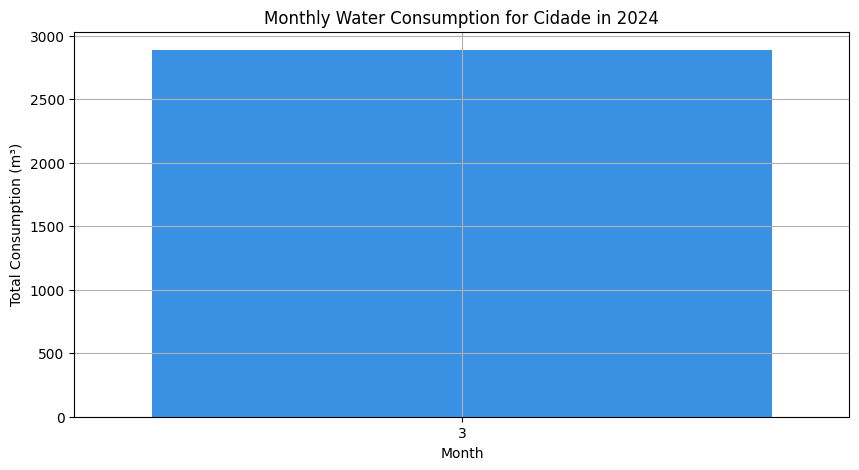

In [10]:
def get_int_input(prompt, min_value=None, max_value=None):
    while True:
        try:
            value = int(input(prompt))
            if (min_value is not None and value < min_value) or (max_value is not None and value > max_value):
                print(f"Value must be between {min_value} and {max_value}.")
            else:
                return value
        except ValueError:
            print("Invalid input. Please enter a valid integer.")

def plot_monthly_consumption(data, year, start_month, end_month, park):
    # Filtrar os dados conforme as especificações do usuário
    park_data = data[(data['Park'] == park) & (data['Year'] == year)]
    monthly_data = park_data[(park_data['Month'] >= start_month) & (park_data['Month'] <= end_month)]
    
    # Agrupar dados por mês e somar o consumo
    monthly_consumption = monthly_data.groupby('Month')['Consumption'].sum().reset_index()
    
    # Usando seaborn para criar o barplot
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Month', y='Consumption', data=monthly_consumption, color='dodgerblue')
    plt.title(f'Monthly Water Consumption for {park} in {year}')
    plt.xlabel('Month')
    plt.ylabel('Total Consumption (m³)')
    plt.grid(True)
    plt.show()

# Input do utilizador para o ano
valid_years = water_data['Year'].unique()
year = int(input(f"Select a year from the list {valid_years}: "))
while year not in valid_years:
    print("Invalid year. Please try again.")
    year = int(input(f"Select a year from the list {valid_years}: "))

# Input do utilizador para o mês de início
min_month = water_data['Month'].min()
max_month = water_data['Month'].max()

# Substitua as chamadas para input() por get_int_input() com as mensagens e validações apropriadas
# Exemplo de como chamar a função:
start_month = get_int_input(f"Select a start month between {min_month} and {max_month}: ", min_month, max_month)
end_month = get_int_input(f"Select an end month between {start_month} and {max_month}: ", start_month, max_month)

# Input do utilizador para a seleção do parque
parks = ['Covelo', 'Cidade', 'Oriental', 'ArcaAgua']
park = input(f"Select a park from the list {parks}: ")
while park not in parks:
    print("Invalid park. Please try again.")
    print(f"Select a park from the list {parks}: ")
    park = input()

# Chamar a função para plotar o consumo mensal de água validado com as entradas do utilizador
plot_monthly_consumption(water_data, year, start_month, end_month, park)


---

### 2. Média dos custos mensais relativos ao consumo de água, para cada parque, em resultado das seguintes especificações dadas pelo utilizador: número de parques a analisar, e identificação do parque.

In [12]:
def calculate_monthly_costs(data, park_ids):
    # Define cost rates
    cost_per_m3 = 0.7
    high_consumption_fee = 1.15
    critical_limit = 1000
    
    # Filter data for the specified parks
    park_data = data[data['Park'].isin(park_ids)].copy()  # Create an explicit copy of the DataFrame
    
    # Calculate monthly costs
    # é preciso .loc, porque senão mostra o aviso SettingWithCopyWarning que você está vendo é comum quando se tenta modificar um DataFrame do pandas. Isso acontece porque o pandas não tem certeza se park_data é uma cópia de data ou uma visualização (ou seja, um subconjunto de data). Modificar uma cópia do DataFrame não afetará o DataFrame original, enquanto modificar uma visualização afetará o DataFrame original.
    # Para evitar esse aviso, você pode usar o método .loc[] para modificar o DataFrame de forma explícita
    park_data.loc[:, 'Cost'] = park_data['Consumption'].apply(
        lambda x: x * cost_per_m3 if x <= critical_limit else critical_limit * cost_per_m3 + (x - critical_limit) * cost_per_m3 * high_consumption_fee)
    
    # Group by park and calculate average monthly cost
    monthly_costs = park_data.groupby(['Park', 'Year', 'Month'])['Cost'].mean().reset_index()
    
    return monthly_costs


# Supondo que water_data é um DataFrame pré-carregado com uma coluna 'Park'
total_parks_list = water_data['Park'].unique()

# Pede ao usuário para introduzir o número de parques que deseja analisar
num_parks_input = input(f"Enter the number of parks you want to analyze (1-{len(total_parks_list)}): ")
num_parks = int(num_parks_input)

selected_park_ids = []

# Pede ao usuário para inserir os nomes dos parques
for i in range(num_parks):
    park_id_input = input(f"Enter park ID number {i+1} (Available parks are: {total_parks_list}): ")
    selected_park_ids.append(park_id_input)

# Call the function with example data
average_monthly_costs = calculate_monthly_costs(water_data, selected_park_ids)
average_monthly_costs


,Park,Year,Month,Cost
0,ArcaAgua,2023,1,3.481935
1,ArcaAgua,2023,2,3.655312
2,ArcaAgua,2023,3,4.961961
3,ArcaAgua,2023,4,5.510662
4,ArcaAgua,2023,5,7.788629
5,ArcaAgua,2023,6,9.624366
6,ArcaAgua,2023,7,12.322482
7,ArcaAgua,2023,8,11.844713
8,ArcaAgua,2023,9,8.300805
9,ArcaAgua,2023,10,5.830274


---

### 3. Considerar o consumo de água de cada dia que é registado. O objetivo é analisar e comparar os indicadores estatísticos entre o parque com o maior e o menor (não nulo) consumo de água. Para estes dois parques, efetue as seguintes tarefas e compare os resultados:
    
#### 3.1. Calcular a média, a mediana, o desvio padrão e o coeficiente de assimetria


In [15]:
# Definir a função para calcular os indicadores estatísticos
def calculate_statistical_indicators(data, park):
    park_data = data[data['Park'] == park]
    park_data = park_data[park_data['Consumption'].notnull()]  # Considerar apenas valores não nulos
    indicators = {
        'Mean': park_data['Consumption'].mean(),
        'Median': park_data['Consumption'].median(),
        'Std Dev': park_data['Consumption'].std(),
        'Skewness': skew(park_data['Consumption'].dropna())
    }
    return indicators

# Calcular os indicadores para cada parque
parks_statistics = {park: calculate_statistical_indicators(water_data, park) for park in water_data['Park'].unique()}

# Converter o dicionário para um DataFrame para facilitar a visualização
parks_statistics_df = pd.DataFrame(parks_statistics).T

# Ordenar o DataFrame pelo valor médio de consumo ('Mean') de forma descendente
parks_statistics_df = parks_statistics_df.sort_values(by='Mean', ascending=False)

parks_statistics_df


,Mean,Median,Std Dev,Skewness
Cidade,116.240589,85.995000,71.724871,3.986003
Oriental,34.571803,27.567848,19.016666,4.051687
Covelo,16.049207,11.898055,10.162275,5.937577
SaoRoque,15.767447,13.944959,10.096174,5.364677
ArcaAgua,8.995993,6.771855,4.852369,2.158431


### Análise do Parque Cidade (Maior Consumidor)

1. **Média de Consumo (116.24 m³)**: O parque Cidade tem a maior média de consumo entre todos os parques analisados. A média é um indicador fundamental para entender o nível geral de consumo, sugerindo que, em média, o parque Cidade consome mais água diariamente do que os outros.

2. **Mediana de Consumo (85.99 m³)**: A mediana, sendo menor que a média, indica a presença de valores extremamente altos de consumo que puxam a média para cima. Isso sugere que, embora muitos dos valores sejam mais baixos, os dias de alto consumo são significativamente elevados.

3. **Desvio Padrão (71.72 m³)**: O alto desvio padrão indica uma variabilidade considerável no consumo de água no parque Cidade. Isso significa que há uma flutuação substancial no consumo diário, com alguns dias tendo consumos muito acima do normal.

4. **Assimetria (3.98)**: Um coeficiente de assimetria positivo e relativamente alto indica que a distribuição do consumo é assimétrica com uma cauda longa para valores maiores. Isso reforça a ideia de que há dias com consumos excecionalmente altos que distorcem a média para cima.

### Análise do Parque ArcaAgua (Menor Consumidor)

1. **Média de Consumo (8.99 m³)**: ArcaAgua tem a menor média de consumo. Este valor sugere que, em termos absolutos, o parque consome menos água em comparação com os outros.

2. **Mediana de Consumo (6.77 m³)**: A mediana mais baixa, próxima à média, indica uma distribuição de consumo mais uniforme e sem a presença marcante de valores extremos.

3. **Desvio Padrão (4.85 m³)**: Um desvio padrão menor em relação ao parque Cidade indica que o consumo no parque ArcaAgua é mais consistente, com menos flutuações diárias significativas.

4. **Assimetria (2.15)**: A assimetria também é positiva mas menos acentuada do que no parque Cidade, indicando que, embora haja dias com consumo acima da média, esses não são tão extremos.

### Conclusão

Conclui-se que o **parque Cidade** é o maior consumidor de água devido à sua média e mediana elevadas, alta variabilidade no consumo diário e presença de dias com consumos extremamente altos, como indicado pelo alto valor de assimetria. Em contraste, o **parque ArcaAgua** é o menor consumidor, com a média e mediana mais baixas, menor variabilidade no consumo e uma distribuição menos assimétrica. Estes indicadores são cruciais para entender não apenas a quantidade de consumo, mas também a consistência e a variabilidade desse consumo, permitindo uma gestão mais eficaz dos recursos hídricos.

---

#### 3.2. Construir tabelas de frequências relativas e absolutas (dados classificados), considerando 5 classes

In [26]:
# Selecionar o parque com maior e menor consumo
top_park = parks_statistics_df.index[0]  # Parque da cidade
bottom_park = parks_statistics_df.index[-1] # Parque de Arca de água

# Função para criar tabelas de frequência relativa e absoluta
def create_frequency_tables(data, park, n_classes=5):
    park_data = data[data['Park'] == park]['Consumption']
    bins = np.linspace(park_data.min(), park_data.max(), n_classes + 1)
    freq_abs = pd.cut(park_data, bins, include_lowest=True).value_counts().sort_index()
    freq_rel = freq_abs / freq_abs.sum() * 100
    
    # Criar DataFrame para a tabela de frequências
    freq_table = pd.DataFrame({
        'Class Range': [f"{bins[i]} - {bins[i+1]}" for i in range(n_classes)],
        'Absolute Frequency': freq_abs.values,
        'Relative Frequency (%)': freq_rel.values
    })
    
    return freq_table

# Criar as tabelas de frequência para o parque com maior e menor consumo
top_park_freq_table = create_frequency_tables(water_data, top_park)
bottom_park_freq_table = create_frequency_tables(water_data, bottom_park)

# Exemplo de formatação e apresentação mais clara
def format_frequency_table(freq_table, park_name):
    print(f"Frequência de Consumo de Água para o parque {park_name}")
    print(freq_table)
    print("\n")

format_frequency_table(top_park_freq_table, top_park)
format_frequency_table(bottom_park_freq_table, bottom_park)


Frequência de Consumo de Água para o parque Cidade
                Class Range  Absolute Frequency  Relative Frequency (%)
0         0.0 - 184.5309375                 386               84.649123
1  184.5309375 - 369.061875                  67               14.692982
2  369.061875 - 553.5928125                   2                0.438596
3   553.5928125 - 738.12375                   0                0.000000
4   738.12375 - 922.6546875                   1                0.219298


Frequência de Consumo de Água para o parque ArcaAgua
          Class Range  Absolute Frequency  Relative Frequency (%)
0       0.0 - 9.84375                 315               69.078947
1   9.84375 - 19.6875                 137               30.043860
2  19.6875 - 29.53125                   2                0.438596
3   29.53125 - 39.375                   1                0.219298
4   39.375 - 49.21875                   1                0.219298




### Parque Cidade (Maior Consumidor)

#### Análise das Classes
- **Classe 1 (0.0 - 184.5309375 m³):**
  - **Frequência Absoluta:** 386 dias
  - **Frequência Relativa:** 84.64%
  - **Interpretação:** Apesar de ser o parque com o maior consumo médio, a maioria dos dias (aproximadamente 84.65%) tem um consumo que pode ser considerado baixo para este parque, mas que é alto quando comparado ao consumo máximo do parque menor consumidor. Isto mostra que, embora o parque tenha picos de consumo elevados, no dia-a-dia o seu consumo não é extremamente alto.

- **Classe 2 (184.5309375 - 369.061875 m³):**
  - **Frequência Absoluta:** 67 dias
  - **Frequência Relativa:** 14.69%
  - **Interpretação:** Uma menor porcentagem de dias mostra um consumo mais elevado, dentro de uma faixa que ainda é gerível, mas significativamente mais alta que a maioria dos dias.

- **Classe 3 (369.061875 - 553.5928125 m³):**
  - **Frequência Absoluta:** 2 dias
  - **Frequência Relativa:** 0.44%
  - **Interpretação:** Dias com consumo moderado são extremamente raros, indicando eventos específicos ou necessidades ocasionais de maior uso de água.

- **Classe 4 (553.5928125 - 738.12375 m³):**
  - **Frequência Absoluta:** 0 dias
  - **Interpretação:** Não houve registro de consumo nesta faixa.

- **Classe 5 (738.12375 - 922.6546875 m³):**
  - **Frequência Absoluta:** 1 dia
  - **Frequência Relativa:** 0.22%
  - **Interpretação:** Um dia excepcional com consumo extremamente alto, possivelmente devido a uma situação única ou emergencial.

### Parque ArcaAgua (Menor Consumidor)

#### Análise das Classes
- **Classe 1 (0.0 - 9.84375 m³):**
  - **Frequência Absoluta:** 315 dias
  - **Frequência Relativa:** 69.08%
  - **Interpretação:** A grande maioria dos dias tem um consumo muito baixo, refletindo uma gestão eficiente e um padrão de uso de água consistente e minimalista.

- **Classe 2 (9.84375 - 19.6875 m³):**
  - **Frequência Absoluta:** 137 dias
  - **Frequência Relativa:** 30.04%
  - **Interpretação:** Uma parte significativa dos dias ainda apresenta um consumo baixo, mas um pouco mais elevado que a classe anterior.

- **Classe 3 (19.6875 - 29.53125 m³):**
  - **Frequência Absoluta:** 2 dias
  - **Frequência Relativa:** 0.44%
  - **Interpretação:** Consumo moderado é raro, indicando dias atípicos.

- **Classe 4 (29.53125 - 39.375 m³) e Classe 5 (39.375 - 49.21875 m³):**
  - **Frequência Absoluta:** 1 dia em cada classe
  - **Frequência Relativa:** 0.22% em cada classe
  - **Interpretação:** Estes são dias excepcionais com consumo mais alto que o usual, muito provavelmente devido a circunstâncias extraordinárias.

### Conclusões
A análise das classes de consumo revela que o parque Cidade, apesar de ter dias com consumos muito baixos comparáveis ao menor consumidor em termos relativos ao seu próprio padrão, possui uma capacidade e incidência para atingir picos de consumo significativamente mais elevados. O parque ArcaAgua, por outro lado, demonstra uma consistência notável no seu baixo consumo, com raros desvios para valores mais altos, refletindo uma gestão de água extremamente controlada e eficiente. Estas informações são cruciais para a gestão dos recursos hídricos, permitindo adaptar estratégias para cada parque baseadas em seu perfil de consumo.

---

#### 3.3. Para cada parque, verifique se os dados têm valores atípicos, utilizando a definição de valores atípicos como valores que se desviam da mediana em mais de 1,5 vezes o intervalo interquartil

In [30]:
# Função para detectar outliers baseada na mediana e IQR
def detect_outliers(data, park):
    park_data = data[data['Park'] == park]['Consumption']

    quartiles = st.quantiles(park_data.dropna(), n=4)
    IQR = quartiles[2] - quartiles[0]
    median = quartiles[1]
    
    lower_bound = median - 1.5 * IQR
    upper_bound = median + 1.5 * IQR
    
    outliers = park_data[(park_data < lower_bound) | (park_data > upper_bound)]
    return outliers, lower_bound, upper_bound, quartiles

# Aplicar a função e obter outliers
top_outliers, top_lb, top_ub, top_quartiles = detect_outliers(water_data, top_park)
bottom_outliers, bottom_lb, bottom_ub, bottom_quartiles = detect_outliers(water_data, bottom_park)

# Preparar para imprimir resultados
print(f"Outliers para {top_park} (limites [{top_lb:.2f}, {top_ub:.2f}]):")
print(top_outliers.describe())
print(f"Outliers para {bottom_park} (limites [{bottom_lb:.2f}, {bottom_ub:.2f}]):")
print(bottom_outliers.describe())


Outliers para Cidade (limites [-39.14, 211.13]):
count     62.000000
mean     246.025536
std       96.705795
min      212.407650
25%      221.257969
50%      226.905870
75%      234.649898
max      922.654688
Name: Consumption, dtype: float64
Outliers para ArcaAgua (limites [-2.83, 16.37]):
count    59.000000
mean     18.410093
std       4.646070
min      16.509248
25%      17.019844
50%      17.360241
75%      17.893230
max      49.218750
Name: Consumption, dtype: float64


## Conclusão da Análise de Outliers nos Consumos de Água dos Parques Cidade e ArcaAgua

### Contexto
Foi realizado uma análise meticulosa para identificar os dias de consumo atípico de água nos parques Cidade e ArcaAgua, com base na técnica de intervalo interquartil (IQR). Os limites para considerar um consumo como atípico foram estabelecidos usando 1,5 vezes o IQR acima e abaixo da mediana dos dados.

### Resultados para o Parque Cidade
O parque Cidade, conhecido por ser o maior consumidor de água, apresentou 62 dias classificados como atípicos durante o período analisado. Estes dias de consumo atípico estão caracterizados por:
- **Intervalo de Outliers:** Os consumos nestes dias variam de 212.41 m³ a 922.65 m³.
- **Consumo Médio nos Dias Atípicos:** O consumo médio nestes dias foi de 246.03 m³.
- **Desvio Padrão:** A variação no consumo durante estes dias foi consideravelmente alta, com um desvio padrão de 96.71 m³, indicando uma flutuação significativa nos valores de consumo.

### Análise
Este padrão sugere que, embora o consumo médio diário no parque Cidade seja elevado, existem dias específicos onde o consumo excede em muito os padrões habituais. Estes picos podem ser atribuídos a eventos especiais, atividades sazonais que requerem maior uso de água, ou possíveis ineficiências ou falhas no sistema de gestão de água.

### Resultados para o Parque ArcaAgua
Por outro lado, o parque ArcaAgua, que geralmente tem um consumo mais moderado, também mostrou ter 59 dias com consumos considerados atípicos, com características:
- **Intervalo de Outliers:** Os consumos variaram entre 16.51 m³ e 49.22 m³.
- **Consumo Médio nos Dias Atípicos:** Foi de 18.41 m³.
- **Desvio Padrão:** O desvio padrão foi de 4.65 m³, sugerindo uma menor variação nos consumos atípicos comparativamente ao Cidade.

---

#### 3.4. Representar graficamente os dados através de histogramas com 10 e 100 classes.

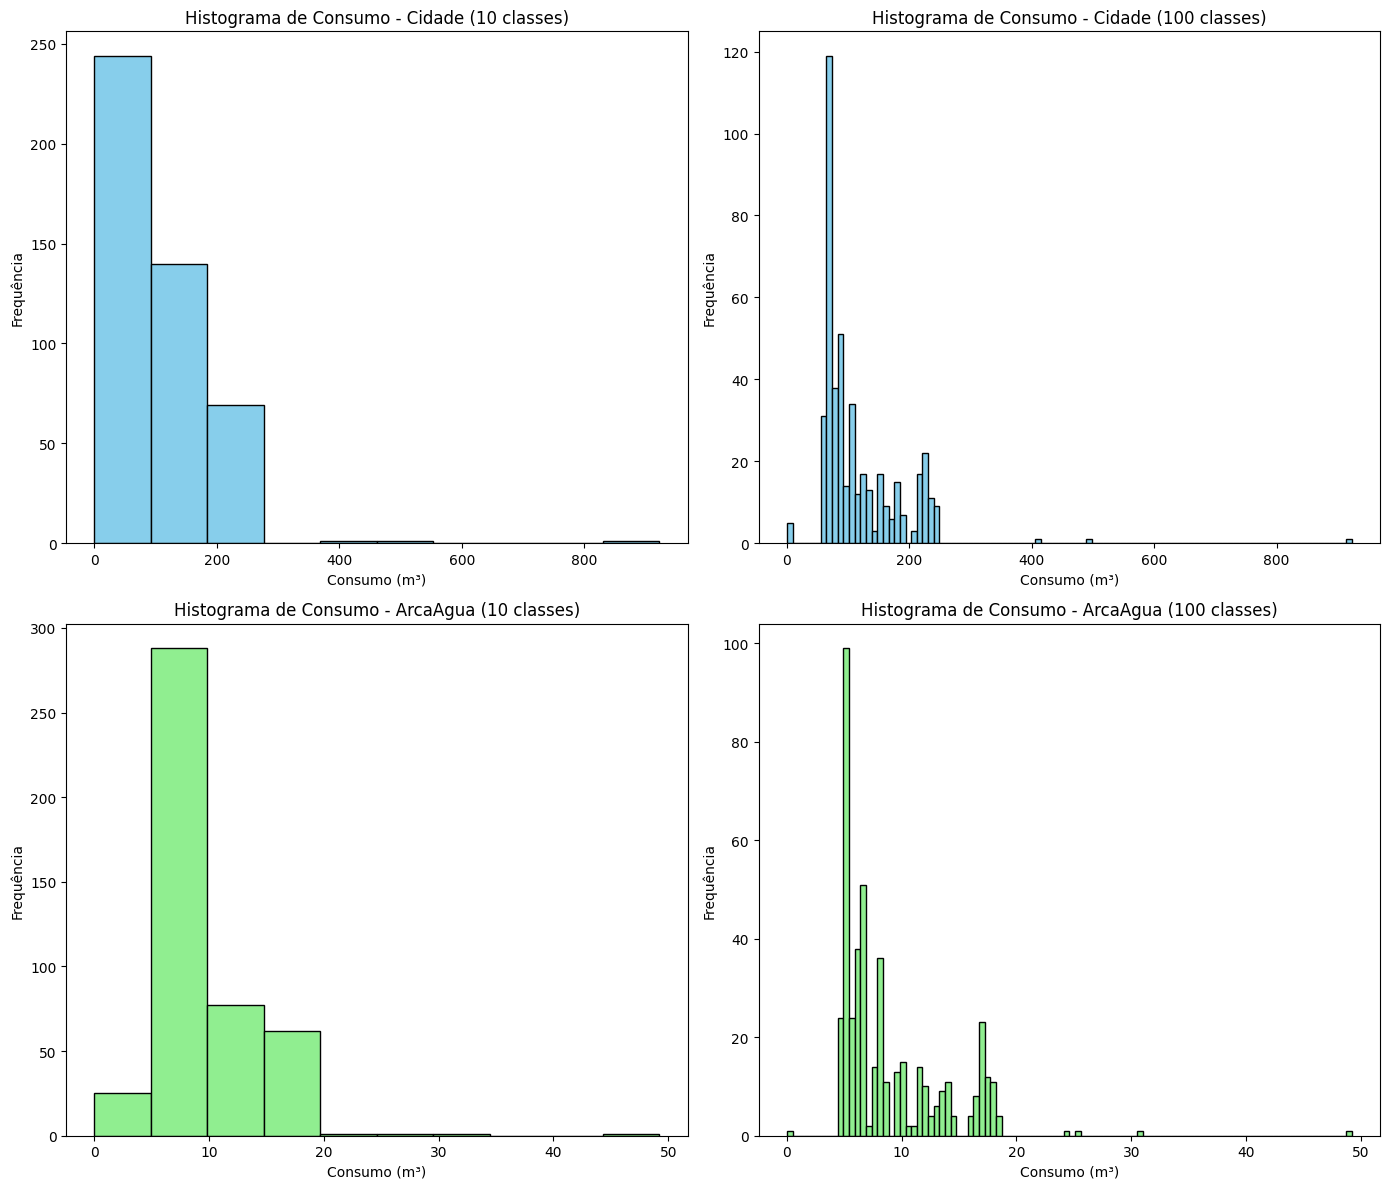

In [33]:
# Criar histogramas
plt.figure(figsize=(14, 12))

# Histograma para o parque com maior consumo com 10 classes
plt.subplot(2, 2, 1)
plt.hist(water_data[water_data['Park'] == top_park]['Consumption'].dropna(), bins=10, color='skyblue', edgecolor='black')
plt.title(f'Histograma de Consumo - {top_park} (10 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com maior consumo com 100 classes
plt.subplot(2, 2, 2)
plt.hist(water_data[water_data['Park'] == top_park]['Consumption'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title(f'Histograma de Consumo - {top_park} (100 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com menor consumo com 10 classes
plt.subplot(2, 2, 3)
plt.hist(water_data[water_data['Park'] == bottom_park]['Consumption'].dropna(), bins=10, color='lightgreen', edgecolor='black')
plt.title(f'Histograma de Consumo - {bottom_park} (10 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com menor consumo com 100 classes
plt.subplot(2, 2, 4)
plt.hist(water_data[water_data['Park'] == bottom_park]['Consumption'].dropna(), bins=100, color='lightgreen', edgecolor='black')
plt.title(f'Histograma de Consumo - {bottom_park} (100 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


## Análise dos Histogramas de Consumo de Água nos Parques Cidade e ArcaAgua

### Parque Cidade
- **Histograma com 10 Classes:** A maioria dos consumos está concentrada na faixa até 200 m³, com uma frequência muito alta para consumos menores que 100 m³, e uma redução gradual para consumos maiores.
- **Histograma com 100 Classes:** Oferece uma visão mais detalhada da distribuição, evidenciando a concentração de dias com consumos entre 50 m³ e 150 m³. Existem picos específicos dentro desta faixa, sugerindo padrões regulares de consumo elevado.

### Análise do Parque Cidade
O consumo no Parque Cidade é caracteristicamente variado, com a maior parte dos consumos situando-se em níveis moderados, mas com ocorrências frequentes de consumos relativamente altos. A presença de classes com consumos superiores a 600 m³, embora menos frequentes, indica dias atípicos com demandas de água muito superiores ao normal, possivelmente devido a eventos ou atividades específicas que exigem um grande volume de recursos hídricos.

### Parque ArcaAgua
- **Histograma com 10 Classes:** Mostra uma concentração esmagadora dos consumos abaixo de 10 m³, com uma queda acentuada para consumos maiores.
- **Histograma com 100 Classes:** Aprecia-se a consistência deste padrão, com a maioria esmagadora dos consumos muito abaixo de 20 m³, e poucas ocorrências acima deste valor.

### Análise do Parque ArcaAgua
O Parque ArcaAgua demonstra um padrão de consumo extremamente estável e baixo, com a maior parte dos dias apresentando consumos mínimos. O gráfico com 100 classes ajuda a entender que, mesmo dentro de um regime de baixo consumo, existem variações sutis que são importantes para o manejo eficaz dos recursos hídricos.